In [20]:
%load_ext autoreload
%autoreload 2
%run -i loader/dataloader_hurricane.py

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from loader.dataloader_hurricane import *

data_df=pd.read_csv("../STOFSatl_hydro.csv", low_memory=False).dropna()
#station_info = pd.read_csv('stations_Ian.csv')
data_df = data_df[(data_df['storm'] == 'IAN')].dropna()
# Remove outliers
std = data_df['offset'].std()
data_df = data_df.where(data_df['offset'].abs() < 3*np.abs(std)).dropna()


# data_df

In [22]:

import matplotlib.pyplot as plt
import matplotlib as mpl

import cartopy.crs as crs
import cartopy.feature as cfeature

def scale_bar(ax, length=None, location=(0.5, 0.05), linewidth=3):
    """
    ax is the axes to draw the scalebar on.
    length is the length of the scalebar in km.
    location is center of the scalebar in axis coordinates.
    (ie. 0.5 is the middle of the plot)
    linewidth is the thickness of the scalebar.
    """
    #Get the limits of the axis in lat long
    llx0, llx1, lly0, lly1 = ax.get_extent(crs.PlateCarree())
    #Make tmc horizontally centred on the middle of the map,
    #vertically at scale bar location
    sbllx = (llx1 + llx0) / 2
    sblly = lly0 + (lly1 - lly0) * location[1]
    tmc = crs.TransverseMercator(sbllx, sblly)
    #Get the extent of the plotted area in coordinates in metres
    x0, x1, y0, y1 = ax.get_extent(tmc)
    #Turn the specified scalebar location into coordinates in metres
    sbx = x0 + (x1 - x0) * location[0]
    sby = y0 + (y1 - y0) * location[1]

    #Calculate a scale bar length if none has been given
    #(Theres probably a more pythonic way of rounding the number but this works)
    if not length: 
        length = (x1 - x0) / 5000 #in km
        ndim = int(np.floor(np.log10(length))) #number of digits in number
        length = round(length, -ndim) #round to 1sf
        #Returns numbers starting with the list
        def scale_number(x):
            if str(x)[0] in ['1', '2', '5']: return int(x)        
            else: return scale_number(x - 10 ** ndim)
        length = scale_number(length) 

    #Generate the x coordinate for the ends of the scalebar
    bar_xs = [sbx - length * 500, sbx + length * 500]
    #Plot the scalebar
    ax.plot(bar_xs, [sby, sby], transform=tmc, color='k', linewidth=linewidth)
    #Plot the scalebar label
    ax.text(sbx, sby, str(length) + ' km', transform=tmc,
            horizontalalignment='center', verticalalignment='bottom')

c:\Users\stefanos\Documents\venv\pytorch\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


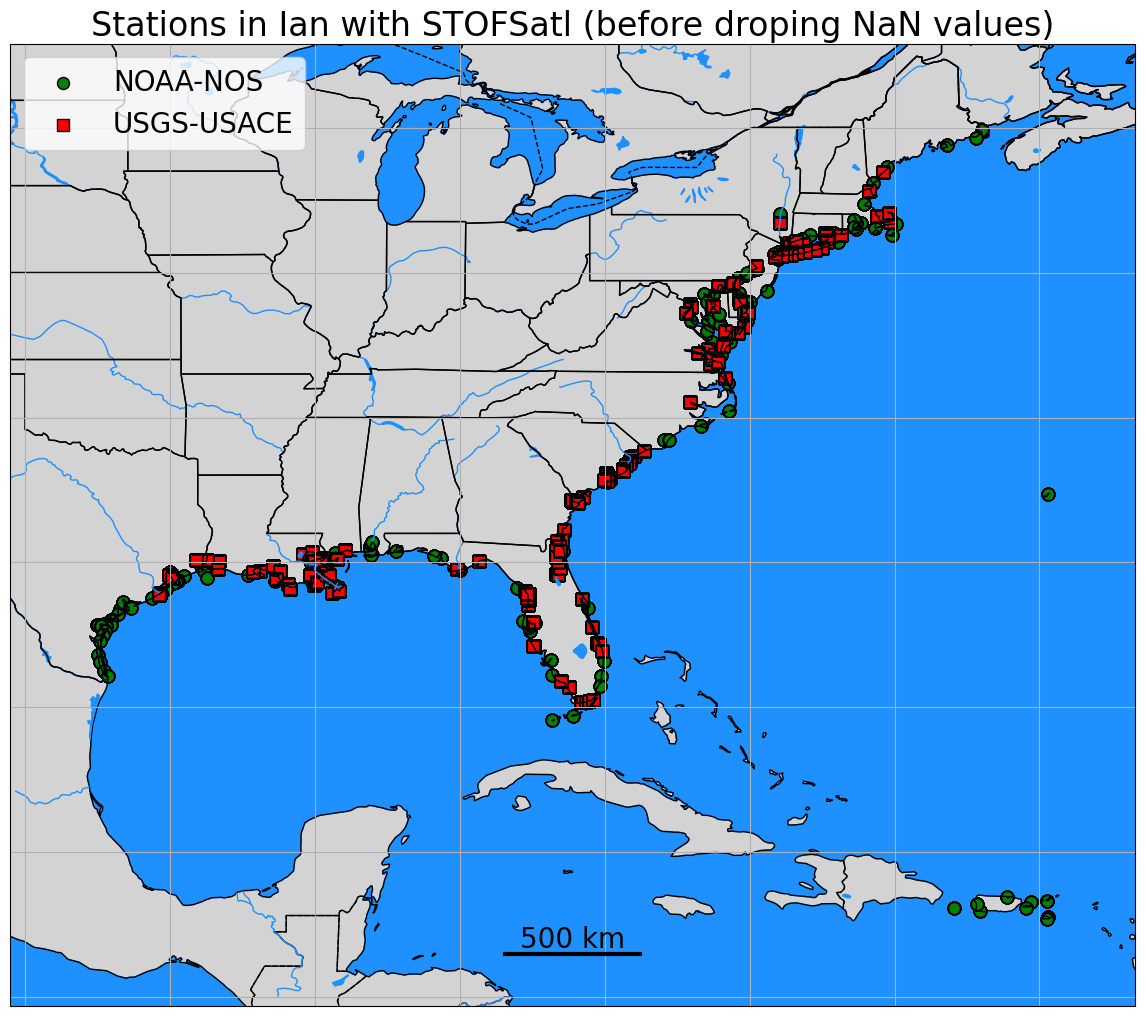

No. of common stations before droping NaN values: 297


In [23]:
station_info_df_NOOA = data_df[(data_df['agency'] == 'NOAA_NOS') | (data_df['agency'] == 'TCOON')]
station_info_df_USGS = data_df[(data_df['agency'] == 'USGS') | (data_df['agency'] == 'USACE')]



plt.rcParams['figure.figsize'] = [25, 12.5]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

im1 = ax.scatter(station_info_df_NOOA['x'], station_info_df_NOOA['y'], c = 'green',
                  edgecolors='black',
                    s=75,
                      alpha=1.0,
                        label='NOAA-NOS')
im2 = ax.scatter(station_info_df_USGS['x'], station_info_df_USGS['y'], c = 'red',
                  marker = 's',
                    edgecolors='black',
                      s=75, alpha=1.0,
                        label='USGS-USACE')

plt.xlim((data_df['x'].min()-3, data_df['x'].max()+3))
plt.ylim((data_df['y'].min()-3, data_df['y'].max()+3))

plt.legend()
scale_bar(ax, 500)
plt.title('Stations in Ian with STOFSatl (before droping NaN values)')
plt.show()

print("No. of common stations before droping NaN values:", len(data_df['station_id'].unique()))


In [24]:
# Constant config to use througout
config = {
    'BATCH_SIZE': 15,
    'EPOCHS': 100,
    'WEIGHT_DECAY': 5e-4,
    'INITIAL_LR': 3e-3,
    'CHECKPOINT_DIR': './runs',
    'N_PRED': 9,
    'N_HIST': 15,
    'DROPOUT': 0.2,
    # number of possible 5 minute measurements per day
    # number of days worth of data in the dataset
    # If false, use GCN paper weight matrix, if true, use GAT paper weight matrix
    'USE_GAT_WEIGHTS': True,
    'SPLITS': (0.60, 0.20, 0.20)
}
# Number of possible windows in a day
# config['N_SLOT']= config['N_DAY_SLOT'] - (config['N_PRED']+config['N_HIST']) + 1

c:\Users\stefanos\Documents\venv\pytorch\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


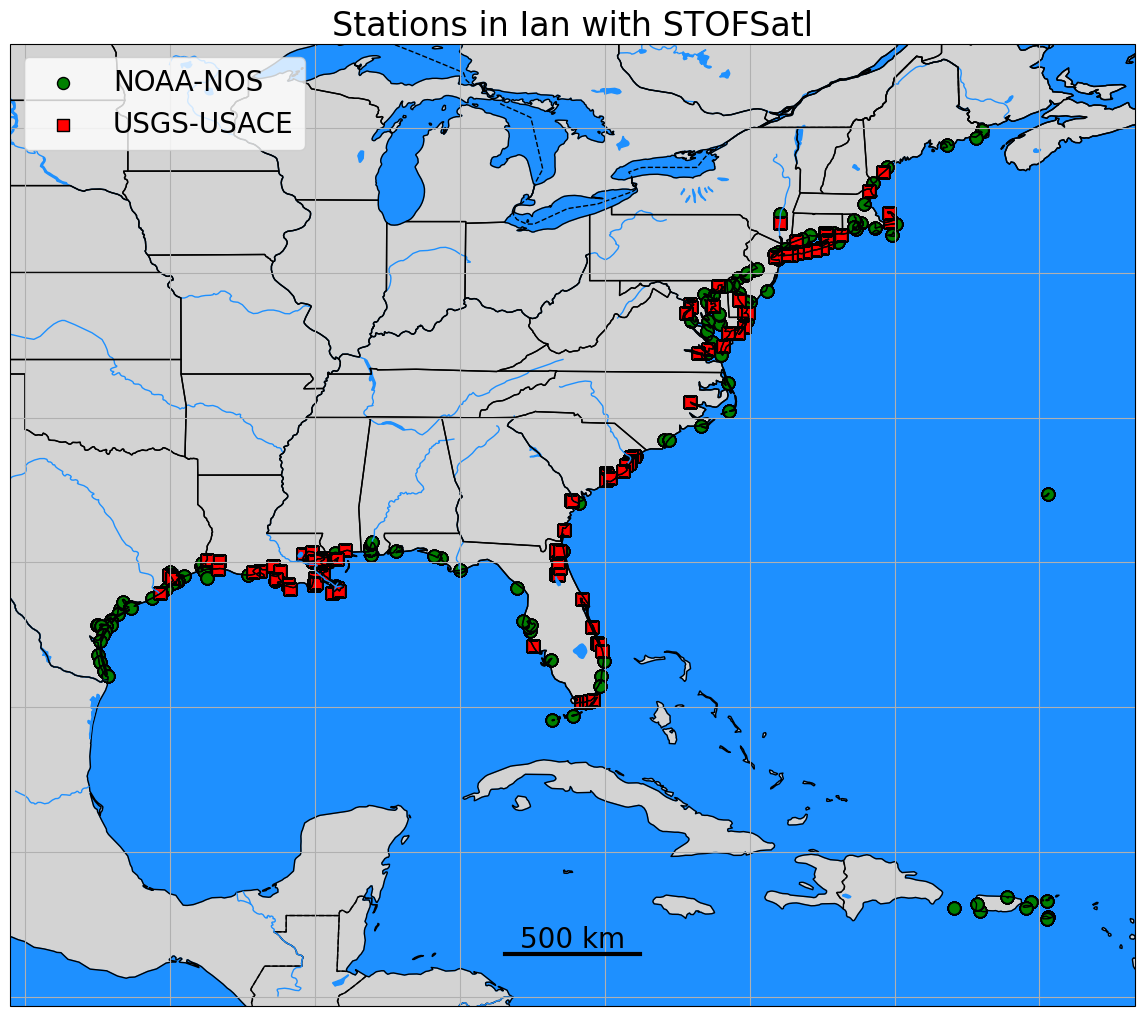

Number of common stations after droping NaN values
 230


In [25]:
Ids=data_df['station_id'].unique()   
station_df=create_stationDf(data_df,Ids, 'offset')
config['N_NODE'] = station_df.shape[1]
data_df_no_nan = data_df[data_df['station_id'].isin(station_df.columns)]
station_info_df_NOOA = data_df_no_nan[(data_df_no_nan['agency'] == 'NOAA_NOS') | (data_df_no_nan['agency'] == 'TCOON')]
station_info_df_USGS = data_df_no_nan[(data_df_no_nan['agency'] == 'USGS') | (data_df_no_nan['agency'] == 'USACE')]



plt.rcParams['figure.figsize'] = [25, 12.5]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

im1 = ax.scatter(station_info_df_NOOA['x'], station_info_df_NOOA['y'], c = 'green',
                  edgecolors='black',
                    s=75,
                      alpha=1.0,
                        label='NOAA-NOS')
im2 = ax.scatter(station_info_df_USGS['x'], station_info_df_USGS['y'], c = 'red',
                  marker = 's',
                    edgecolors='black',
                      s=75, alpha=1.0,
                        label='USGS-USACE')

plt.xlim((data_df_no_nan['x'].min()-3, data_df_no_nan['x'].max()+3))
plt.ylim((data_df_no_nan['y'].min()-3, data_df_no_nan['y'].max()+3))

plt.legend()
scale_bar(ax, 500)
plt.title('Stations in Ian with STOFSatl')
plt.show()

print("Number of common stations after droping NaN values\n", len(station_df.columns.values))


In [26]:
station_df_train, station_df_val, station_df_test = get_splits_hurricanes(station_df, config['SPLITS'])
print(len(station_df))
print(len(station_df_train))
print(len(station_df_val))
print(len(station_df_test))
# Ids_test=station_df_train.columns
# # correlation_mat=[]
# correlation_mat=np.zeros([len(Ids_test), len(Ids_test)])

143
85
21
37


In [27]:
train_gnn, val_gnn, test_gnn, scaler=prepare_gnn_data(data_df, config, W_mask=1000, Corr_mask=0.7)

ValueError: negative dimensions are not allowed

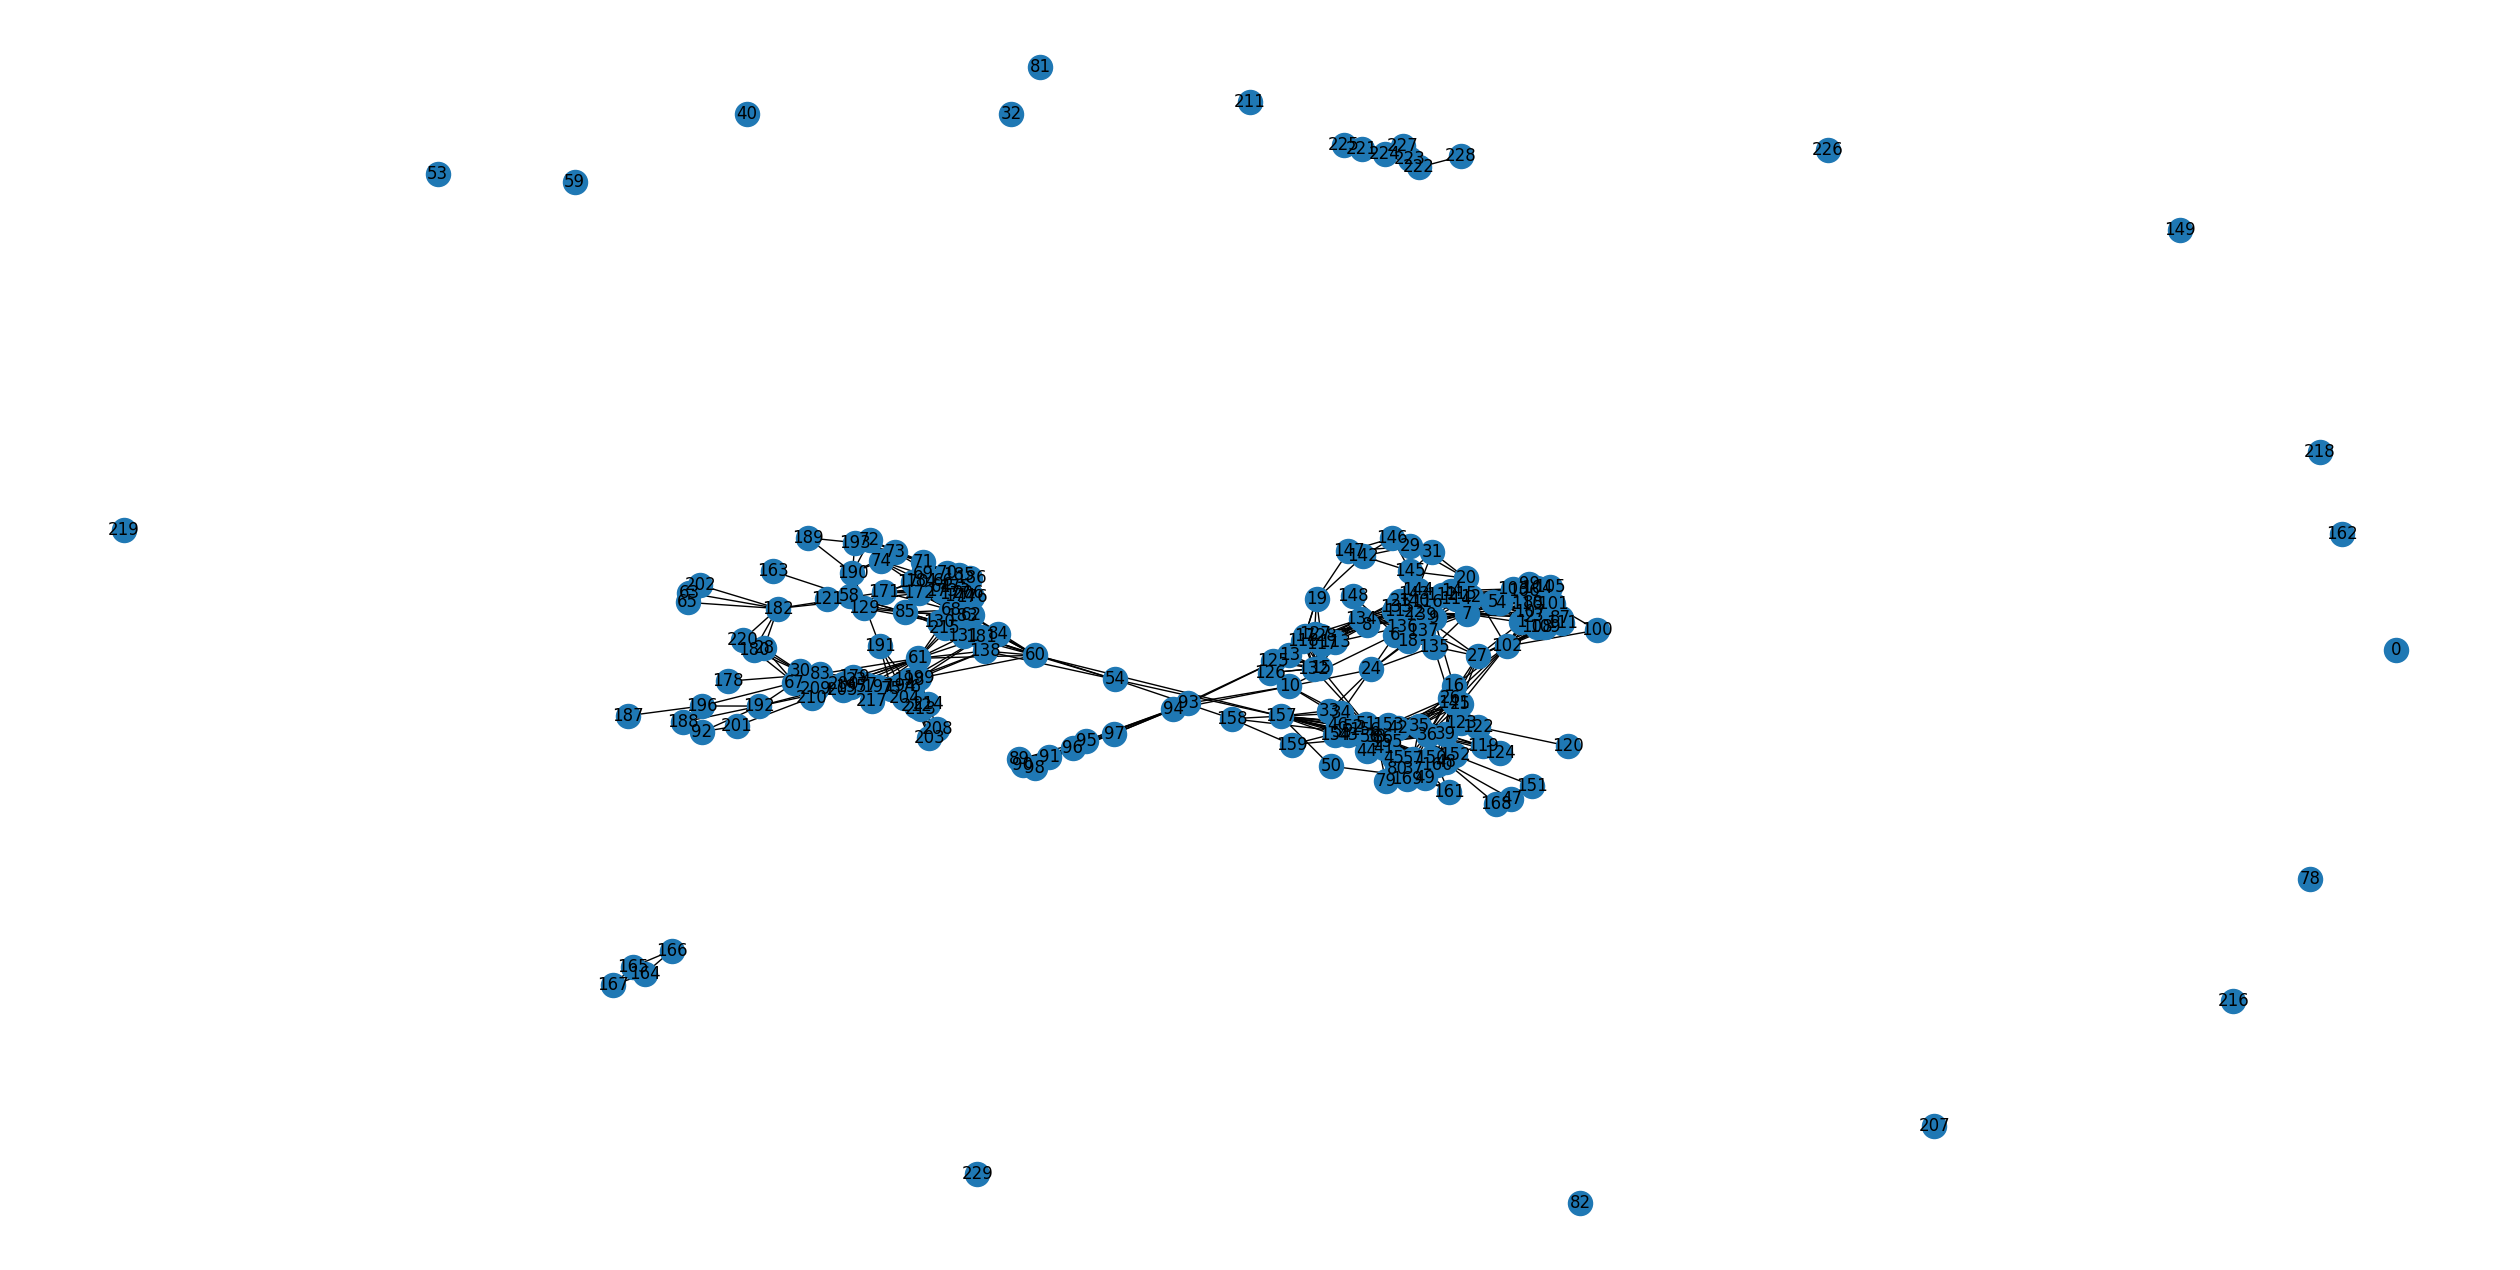

In [9]:
import networkx as nx
from torch_geometric.utils import to_networkx

g = to_networkx(train_gnn[0], to_undirected=True)
nx.draw(g, with_labels=True)
plt.show()

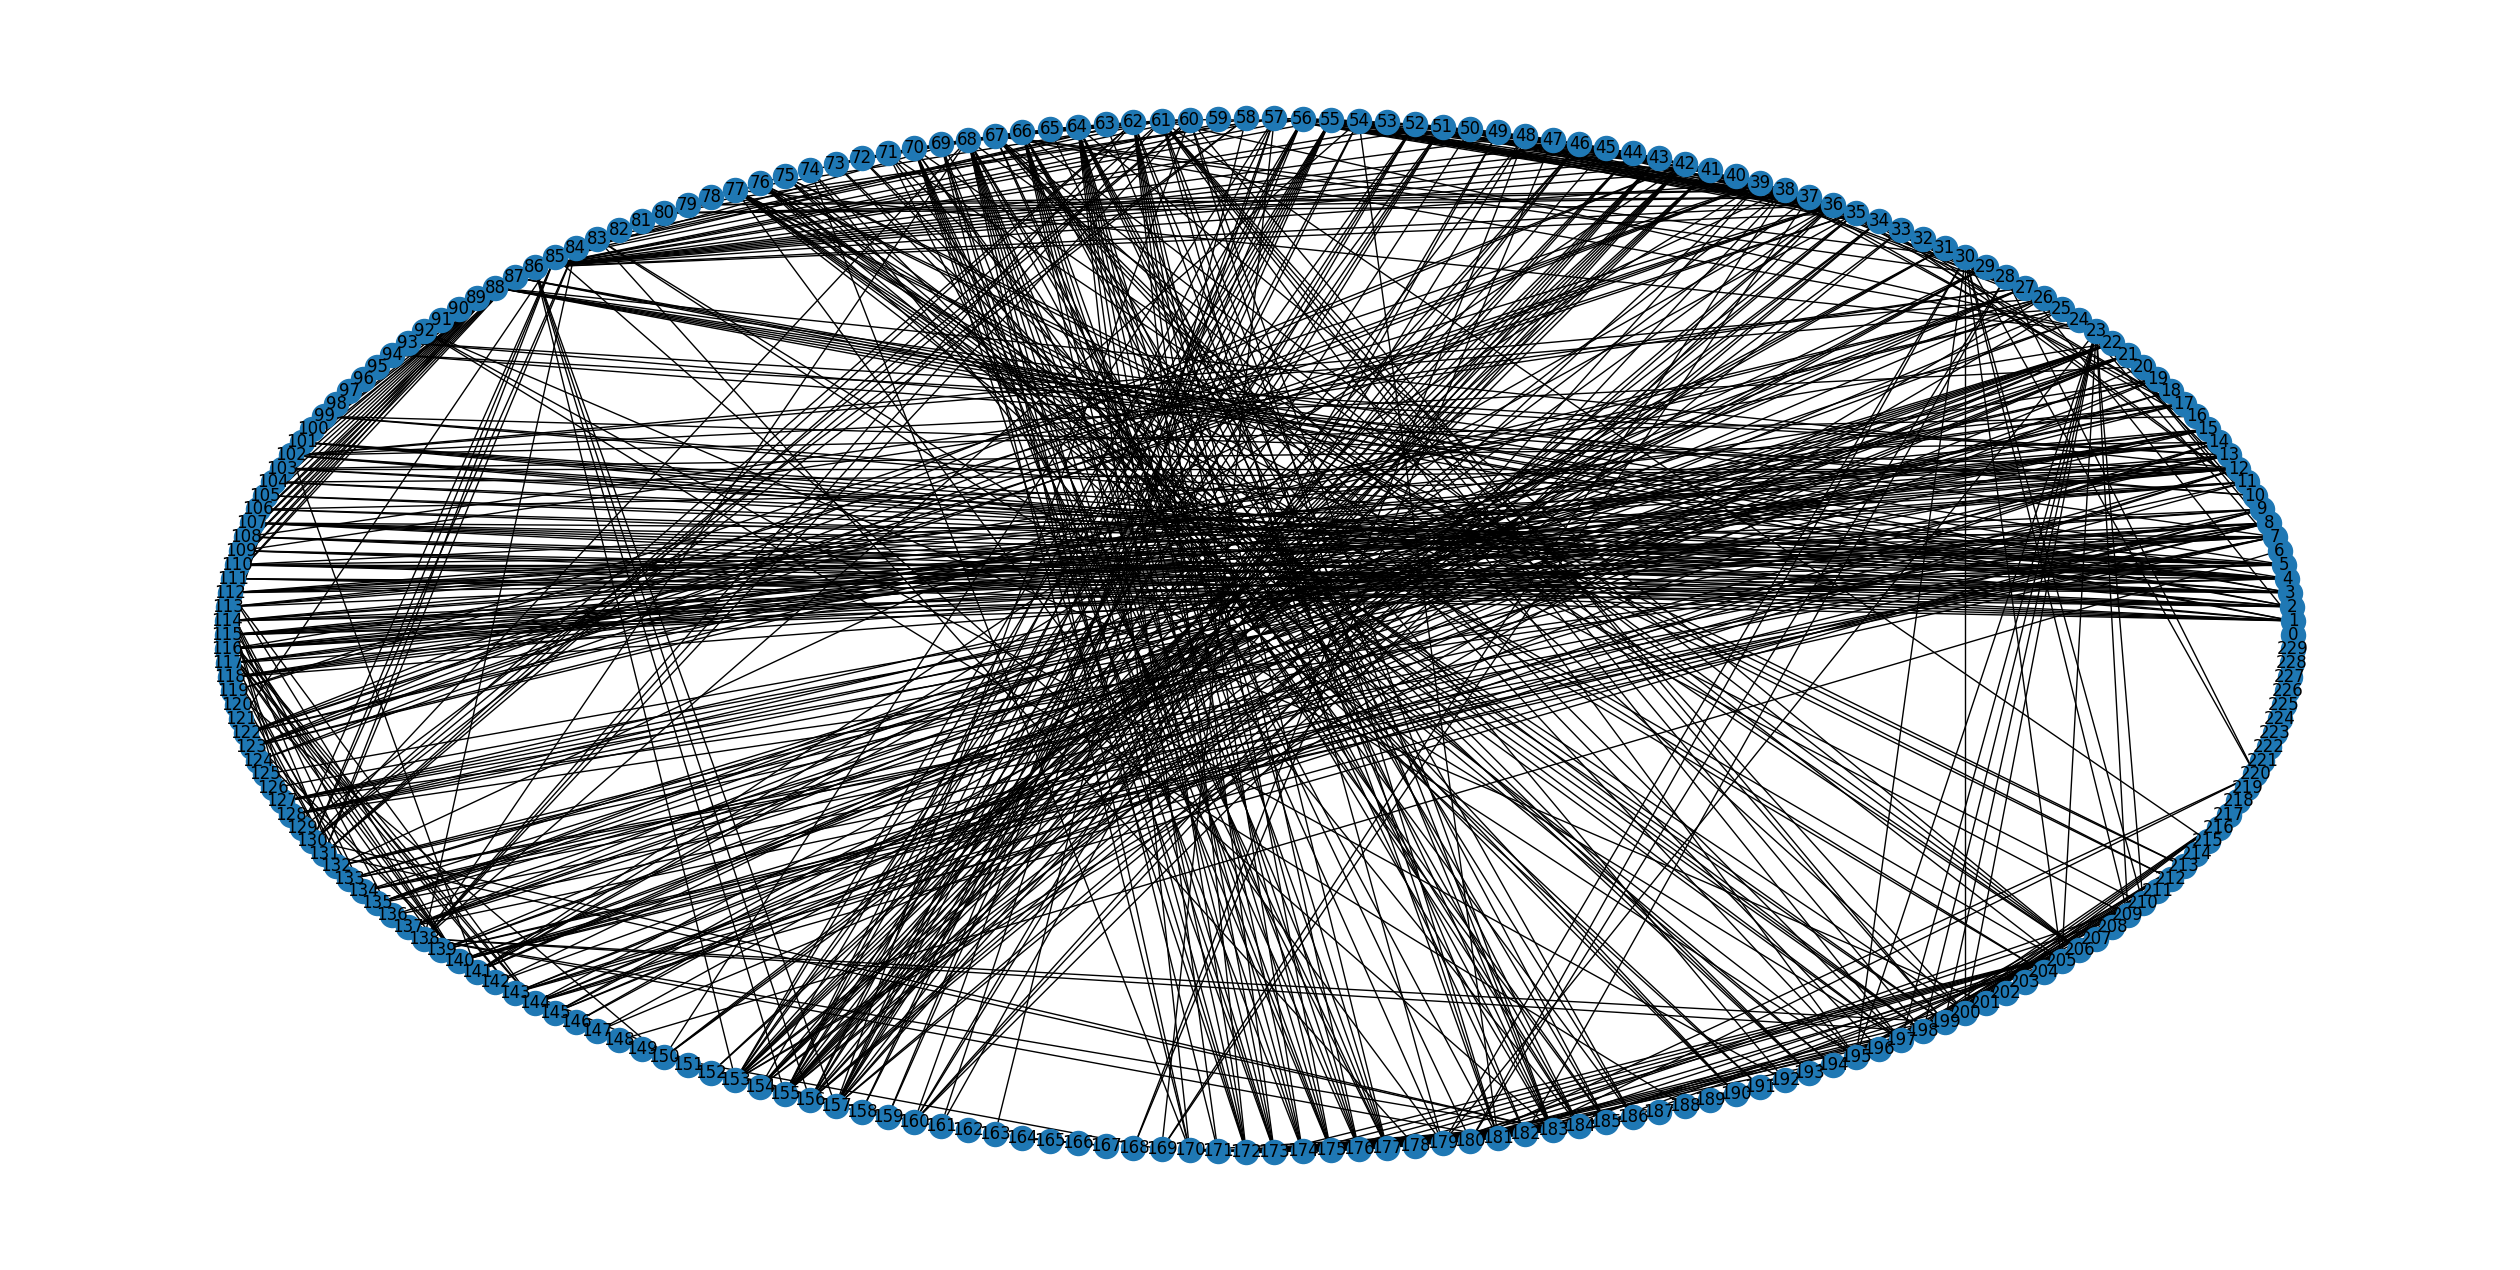

In [10]:
# g = to_networkx(test_gnn[0])
nx.draw_circular(g, with_labels=True)
plt.show()

c:\Users\stefanos\Documents\venv\pytorch\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


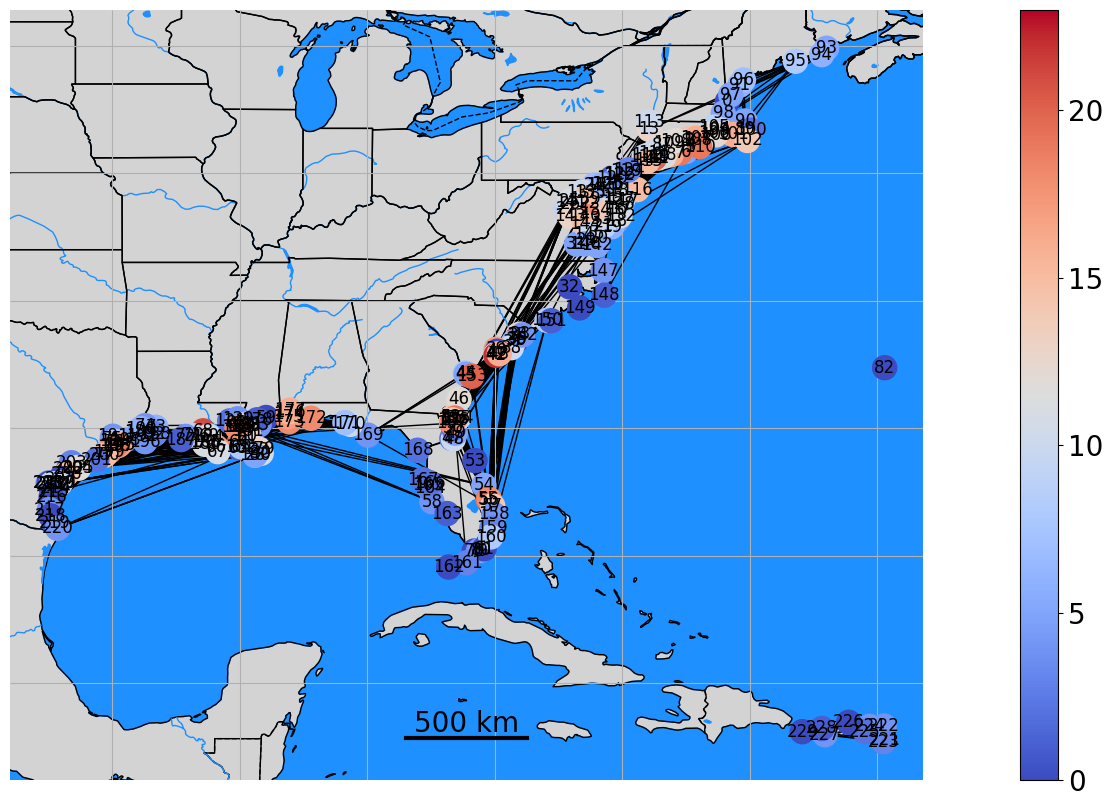

In [ ]:
# drop_list = [station_df_train.columns[53], station_df_train.columns[71], station_df_train.columns[72], station_df_train.columns[73]]
# station_df_train.drop(drop_list, axis=1, inplace=True)
# station_df_val.drop(drop_list, axis=1, inplace=True)
# station_df_test.drop(drop_list, axis=1, inplace=True)

# mapping = {}
positions = {}
names = {}
ids = {}
agencies = {}

for node_name in g.nodes:
    # mapping[node_name]=station_df_train.columns[node_name]
    x = data_df['x'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    y = data_df['y'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    names[node_name] = data_df['station_name'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    ids[node_name] = data_df['station_id'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    agencies[node_name] = data_df['agency'].where(data_df['station_id']==str(station_df_train.columns[node_name])).dropna().unique()[0]
    # positions[station_df.columns[node_name]] = (x,y)
    positions[node_name] = (x,y)

# g = nx.relabel_nodes(g, mapping)
plt.rcParams['figure.figsize'] = [25, 10]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()

d = dict(g.degree)
low, *_, high = sorted(d.values())
norm = mpl.colors.Normalize(vmin=low, vmax=high, clip=True)
mapper = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.coolwarm)

nx.draw(g, pos=positions, with_labels=True, node_color=[mapper.to_rgba(i) for i in d.values()])

# nx.draw_networkx_nodes(g, pos=positions, node_color=[mapper.to_rgba(i) for i in d.values()])
# nx.draw_networkx_labels(g, pos=positions)


plt.xlim((data_df_no_nan['x'].min()-1.5, data_df_no_nan['x'].max()+1.5))
plt.ylim((data_df_no_nan['y'].min()-1.5, data_df_no_nan['y'].max()+1.5))

scale_bar(ax, 500)
fig.colorbar(mapper, ax=ax)
plt.show()

In [12]:
print(len(g[1]))

15


In [16]:
from torch_geometric.loader import DataLoader

train_dataloader = DataLoader(train_gnn, batch_size=config['BATCH_SIZE'], shuffle=True)
val_dataloader = DataLoader(val_gnn, batch_size=config['BATCH_SIZE'], shuffle=True)
test_dataloader = DataLoader(test_gnn, batch_size=config['BATCH_SIZE'], shuffle=False)

In [ ]:
from models.trainer import load_from_checkpoint, model_train, model_test
from torch_geometric.loader import DataLoader


 # Get gpu if you can
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

# Configure and train model
config['N_NODE'] = train_gnn[0].x.shape[0]
print(config['N_NODE'])
model = model_train(train_dataloader, val_dataloader, config, device)

Using cpu
230


Epoch 0: 100%|██████████| 4/4 [00:01<00:00,  3.81it/s]


Loss: 0.15047
Train, MAE: 0.3584747016429901, RMSE: 0.38005331158638
Valid, MAE: 0.36029720306396484, RMSE: 0.39433810114860535


Epoch 1: 100%|██████████| 4/4 [00:00<00:00,  6.57it/s]


Loss: 0.11992


...

Loss: 0.00853


Epoch 98: 100%|██████████| 4/4 [00:00<00:00,  4.68it/s]


Loss: 0.00916


Epoch 99: 100%|██████████| 4/4 [00:00<00:00,  4.83it/s]

Loss: 0.00892


In [17]:
for i, batch in enumerate(test_dataloader):
    batch = batch.to(device)
    if batch.x.shape[0] == 1:
        pass
    else:
        # plt.figure()
        with torch.no_grad():
            pred = model(batch, device)
        
        truth = batch.y.view(pred.shape)
        # print("Truth: ",truth.shape)
        # print("Pred: ", pred.shape)
        # plt.plot(truth)
        # plt.show()


        if i == 0:
            y_pred = torch.zeros(len(test_dataloader), pred.shape[0], pred.shape[1])
            y_truth = torch.zeros(len(test_dataloader), pred.shape[0], pred.shape[1])
        # truth = un_z_score(truth, dataloader.dataset.mean, dataloader.dataset.std_dev)
        # pred = un_z_score(pred, dataloader.dataset.mean, dataloader.dataset.std_dev)
        y_pred[i, :pred.shape[0], :] = pred
        y_truth[i, :pred.shape[0], :] = truth

s = y_truth.shape
num=int(s[1]* s[-1])
num2=config['N_NODE']*s[-1] 
y_truth = y_truth.reshape(s[0], int(num/num2), config['N_NODE'], s[-1])


# Calculate the predicted
s = y_pred.shape
y_pred = y_pred.reshape(s[0], int(num/num2) ,config['N_NODE'], s[-1])

# Inverse scaling
y_truth = scaler.inverse_transform(y_truth.reshape(-1,1)).reshape(y_truth.shape[0], y_truth.shape[1], y_truth.shape[2], y_truth.shape[3])
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1)).reshape(y_pred.shape[0], y_pred.shape[1], y_pred.shape[2], y_pred.shape[3])

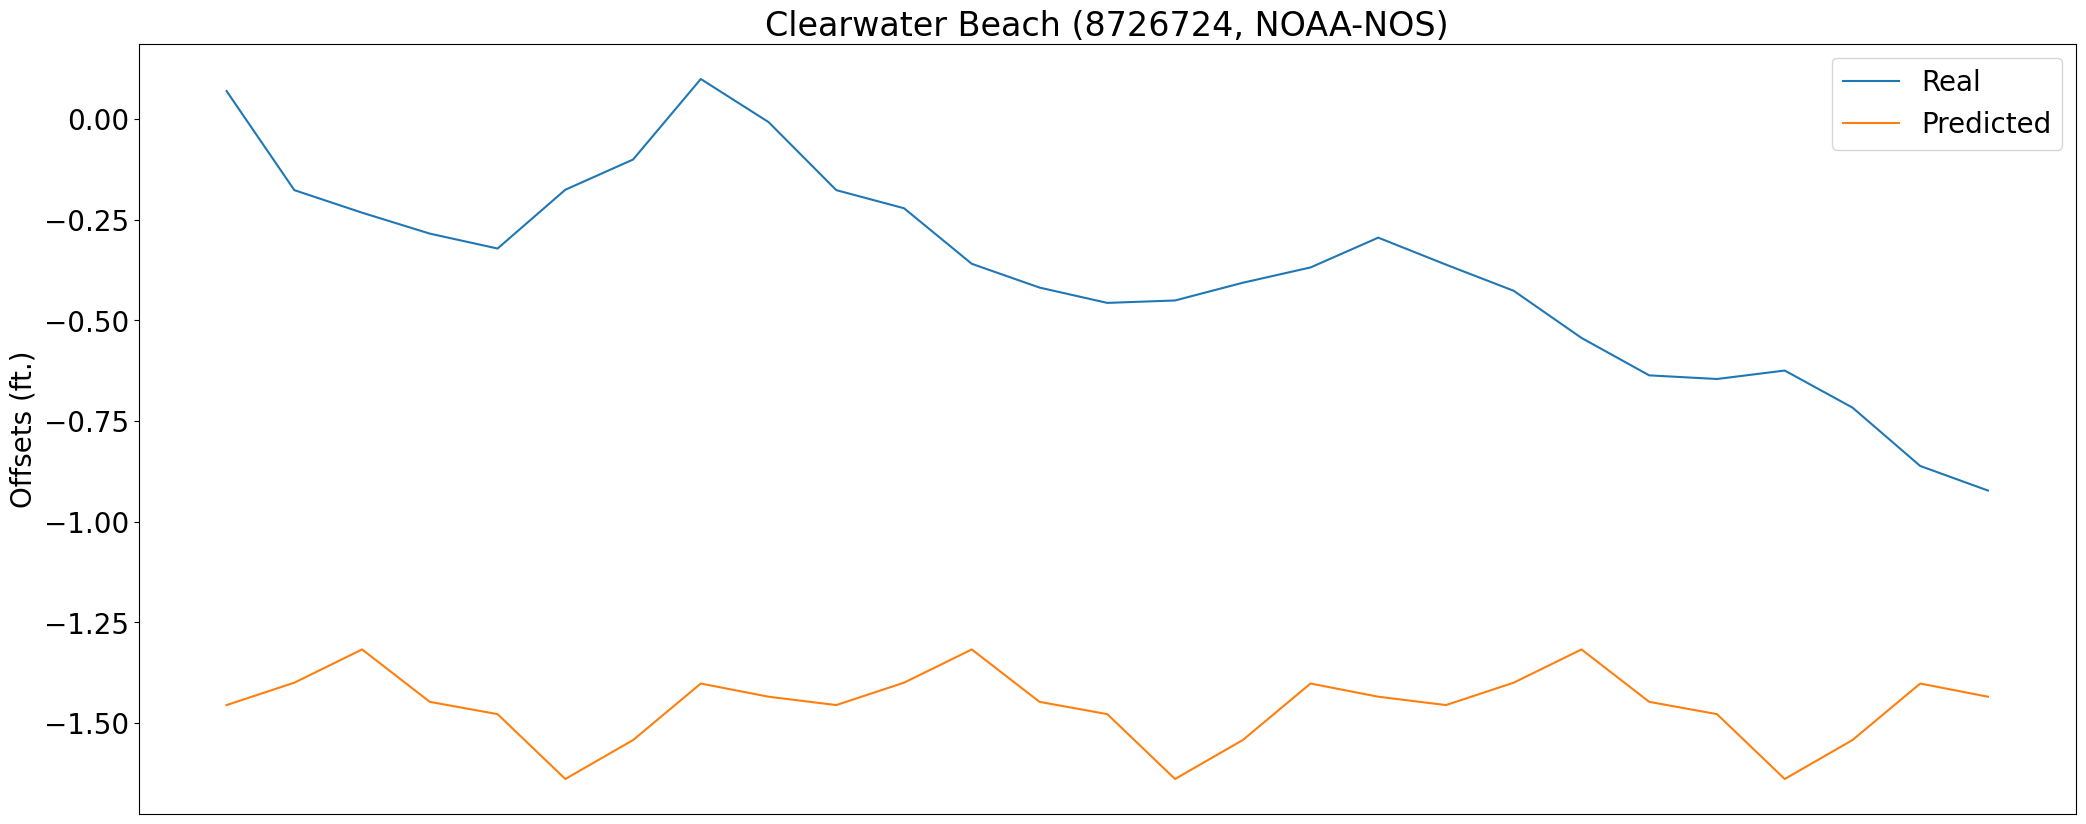

R² = -18.61
RMSE = 1.12
MAE = 1.09


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error, mean_absolute_error


#id='219897993'
# id='8670870'
# id='8661070'
id='8726724'

Ids=station_df.columns.unique()
node = np.where(Ids == id)[0][0]
station_name = data_df[data_df['station_id'] == station_df.columns[node]]['station_name'].values[0]
agency = data_df[data_df['station_id'] == station_df.columns[node]]['agency'].values[0].replace('_','-')


# just get the first prediction out for the nth node
y_truth_station = y_truth[:, :, node, :].flatten()
# Flatten to get the predictions for entire test dataset
# y_truth_station = torch.flatten(y_truth_station)


# just get the first prediction out for the nth node
y_pred_station = y_pred[:, :, node, :].flatten()
# Flatten to get the predictions for entire test dataset
# y_pred_station = torch.flatten(y_pred_station)

plt.plot(y_truth_station, label = 'Real')
plt.plot(y_pred_station, label = 'Predicted')
plt.legend()
plt.ylabel('Offsets (ft.)')
plt.xticks([])
title_str = station_name + f' ({str(id)}, {agency})'
plt.title(title_str)

plt.show()

print("R\u00b2 = {:.2f}".format(r2_score(y_truth_station, y_pred_station)))
print("RMSE = {:.2f}".format(root_mean_squared_error(y_truth_station, y_pred_station)))
print("MAE = {:.2f}".format(mean_absolute_error(y_truth_station, y_pred_station)))


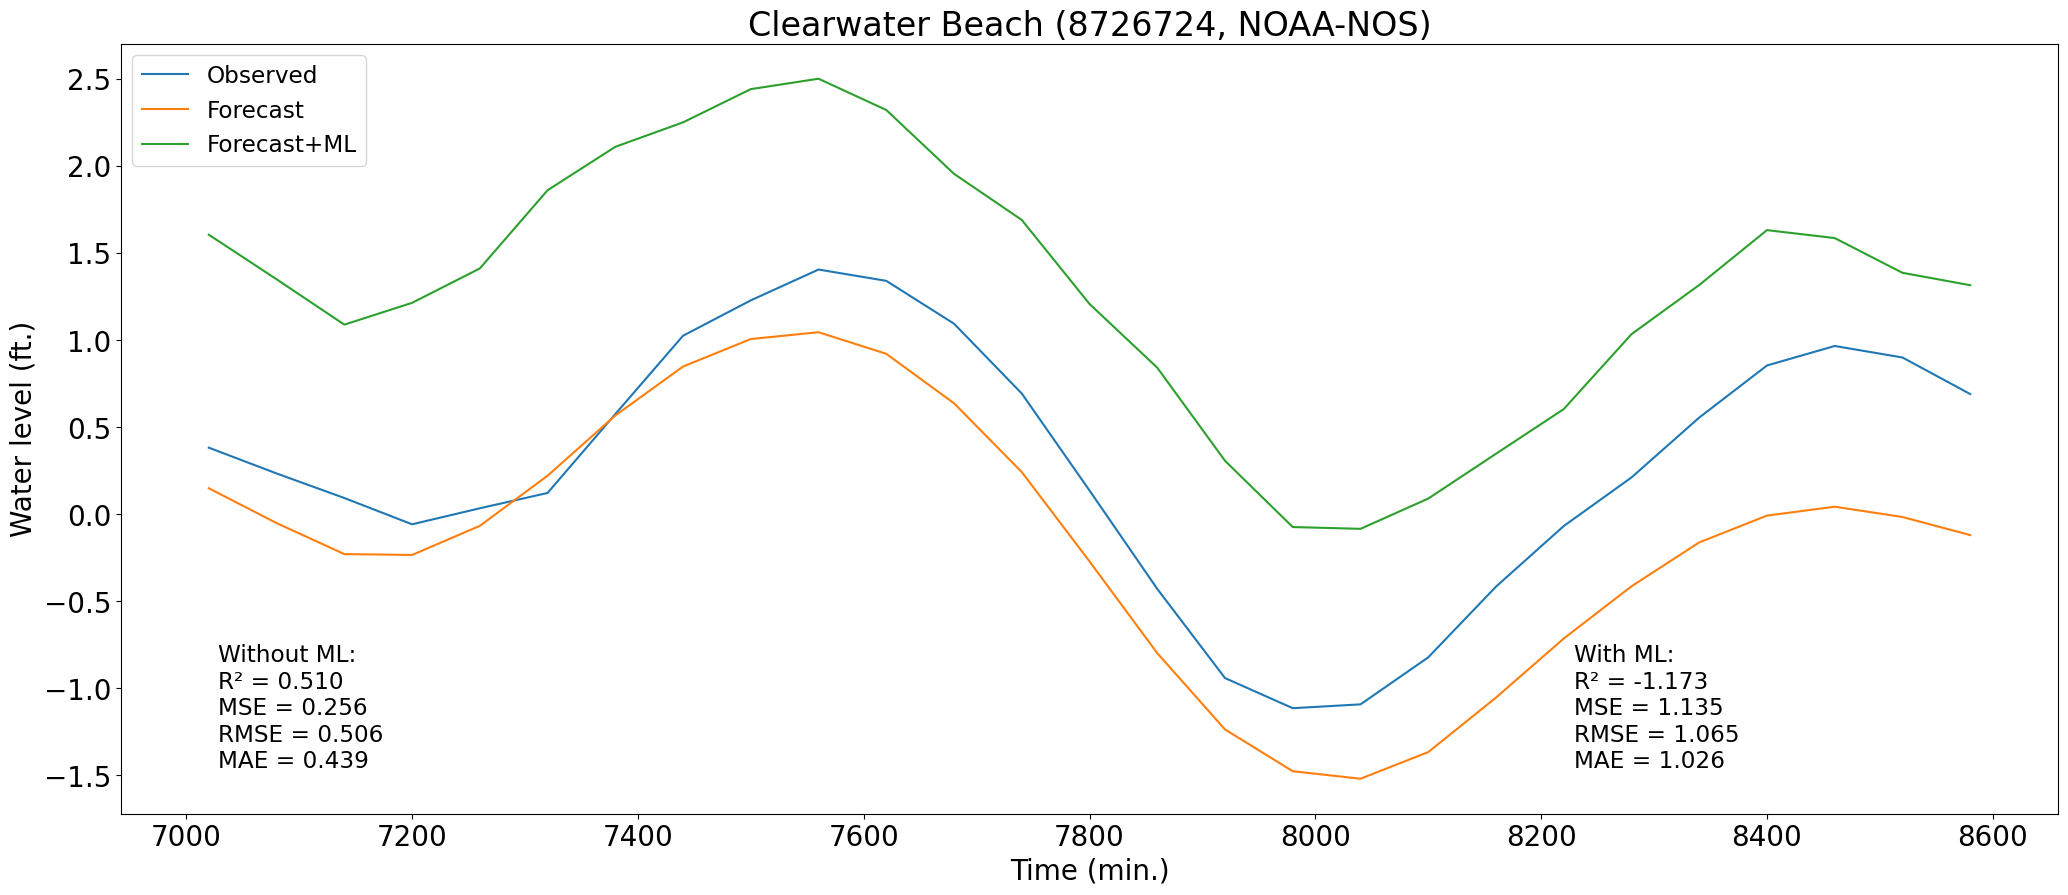

In [ ]:
df_plot=data_df[data_df['station_id']==id].dropna()[['time_UTC_dt', 'observed_data', 'forecast_data', 'offset']]


y_pred_station = np.append(np.ones(config['N_HIST'])*np.nan, y_pred_station)
padding_nan = np.ones(len(df_plot['forecast_data'].values)-len(y_pred_station))*np.nan
y_pred_station = np.append(padding_nan, y_pred_station)

df_plot['corr_forecast_data'] = df_plot['forecast_data'] - y_pred_station

df_plot=df_plot.dropna()

# stats for observed - forecast
r_sq_obs_for = r2_score(df_plot['observed_data'], df_plot['forecast_data'])
mse_obs_for = mean_squared_error(df_plot['observed_data'], df_plot['forecast_data'])
rmse_obs_for = root_mean_squared_error(df_plot['observed_data'], df_plot['forecast_data'])
mae_obs_for = mean_absolute_error(df_plot['observed_data'], df_plot['forecast_data'])
    

# stats for observed - corr. forecast
r_sq_obs_corr = r2_score(df_plot['observed_data'], df_plot['corr_forecast_data'])
mse_obs_corr = mean_squared_error(df_plot['observed_data'], df_plot['corr_forecast_data'])
rmse_obs_corr = root_mean_squared_error(df_plot['observed_data'], df_plot['corr_forecast_data'])
mae_obs_corr = mean_absolute_error(df_plot['observed_data'], df_plot['corr_forecast_data'])

evaluation_stats = [r_sq_obs_for, mse_obs_for, rmse_obs_for, mae_obs_for, r_sq_obs_corr, mse_obs_corr, rmse_obs_corr, mae_obs_corr]

plt.plot(df_plot['time_UTC_dt'], df_plot['observed_data'], label='Observed')
plt.plot(df_plot['time_UTC_dt'], df_plot['forecast_data'], label='Forecast')
plt.plot(df_plot['time_UTC_dt'], df_plot['corr_forecast_data'], label='Forecast+ML')
plt.xlabel('Time (min.)')
plt.ylabel('Water level (ft.)')

# stats for observed - forecast
r_sq_str = "R\u00b2 = {:.3f}\n".format(evaluation_stats[0])
mse_str = "MSE = {:.3f}\n".format(evaluation_stats[1])
rmse_str = "RMSE = {:.3f}\n".format(evaluation_stats[2])
mae_str = "MAE = {:.3f}\n".format(evaluation_stats[3])
stat_str = 'Without ML:\n' + r_sq_str + mse_str + rmse_str + mae_str
annotation = plt.annotate(stat_str, xy=(0.05, 0.025), xycoords='axes fraction', fontsize='small')
annotation.set_bbox(dict(facecolor='white', alpha=0.5, linewidth=0))

# stats for observed - corr. forecast
r_sq_str = "R\u00b2 = {:.3f}\n".format(evaluation_stats[4])
mse_str = "MSE = {:.3f}\n".format(evaluation_stats[5])
rmse_str = "RMSE = {:.3f}\n".format(evaluation_stats[6])
mae_str = "MAE = {:.3f}\n".format(evaluation_stats[7])
stat_str = 'With ML:\n' + r_sq_str + mse_str + rmse_str + mae_str
annotation = plt.annotate(stat_str, xy=(0.75, 0.025), xycoords='axes fraction', fontsize='small')
annotation.set_bbox(dict(facecolor='white', alpha=0.5, linewidth=0))
plt.legend(loc='upper left', fontsize='small')
title_str = station_name + f' ({str(id)}, {agency})'
plt.title(title_str)
# plt.savefig(filename_plot)
plt.show()



In [20]:
# node=100
# model_test(model, test_dataloader, device, node,config)

In [21]:
import os
import json
import tensorflow as tf
import keras 
from keras import Model
from tensorflow.keras.layers import Flatten,LSTM, Dense, Flatten, Embedding, Conv1D, RepeatVector
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.models import Sequential, load_model
from keras.initializers import glorot_uniform 

LSTM_path = r'G:\Documents\LSU\Scripts\TensorFlow\LSTM\Hurricane_Ian_split_stations_timestep-x_y_pred'
model_LSTM = load_model(LSTM_path, compile=False)

data=data_df


# Remove outliers (data outside a 3 sigma range)
# std = data['offset'].std()
# data = data.where(data['offset'].abs() < 3*np.abs(std)).dropna()

# Keep data before and equal to the 7980th minute for training the model
# (data_train)
# and after the 7980th minute for testing it
# (data_test)

data_train = data.where(data['time_UTC_dt'] < 7480.0).dropna()
data_test = data.where(data['time_UTC_dt'] >= 7480.0).dropna()

# split station id's into train and validation
station_ids = data['station_id'].unique()
np.random.seed(2023)
train_ids = np.random.choice(station_ids, int(np.floor(0.8*len(station_ids))), replace=False)
test_ids = np.setdiff1d(station_ids, train_ids)



# split data_train into data_val and data_train according to station IDs
data_val = data_train.where(data_train['station_id'].isin(test_ids)).dropna()
data_train = data_train.where(data_train['station_id'].isin(train_ids)).dropna()

# split a univariate sequence into samples
def split_sequence(data, n_past, n_future):
  #
  # n_past ==> no of past observations
  #
  # n_future ==> no of future observations 
  #
    Ids=data['station_id'].unique()
    
    X, y = list(), list()
    for id in Ids:
        series=data[data['station_id']==id]['offset'] 
        #print(sequence)
        series.reset_index(drop=True,inplace=True)
        # series=series.drop('station_id',axis=1)
        series=series.values
        for window_start in range(len(series)):
            past_end = window_start + n_past
            #print("prev:"+str(past_end))
            future_end = past_end + n_future
            

            if future_end > len(series):
                break
            # slicing the past and future parts of the window
            past, future = series[window_start:past_end], series[past_end:future_end]
            X.append(past)
            y.append(future)
    return np.array(X), np.array(y)

n_past = 15
n_future = 9

x_train, y_train = split_sequence(data_train, n_past, n_future)
x_val, y_val = split_sequence(data_val, n_past, n_future)
x_test, y_test = split_sequence(data_test, n_past, n_future)

# Scale data

X_scaler = MinMaxScaler().fit(x_train)
x_train = X_scaler.transform(x_train)
x_val = X_scaler.transform(x_val)
x_test = X_scaler.transform(x_test)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_val = x_val.reshape((x_val.shape[0], x_val.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

y_train = y_train.reshape((y_train.shape[0], y_train.shape[1], 1))
y_val = y_val.reshape((y_val.shape[0], y_val.shape[1], 1))
y_test = y_test.reshape((y_test.shape[0], y_test.shape[1], 1))




y_scaler = MinMaxScaler().fit(y_train.reshape(-1,1))

for col in range(n_future):
    y_train[:,col] = y_scaler.transform(y_train[:,col])
    y_val[:,col] = y_scaler.transform(y_val[:,col])
    y_test[:,col] = y_scaler.transform(y_test[:,col])

y_test = y_test.reshape(y_test.shape[0]*y_test.shape[1])

def split_sequence_single_station(data, n_past=15, n_future=9):
  #
  # n_past ==> no of past observations
  #
  # n_future ==> no of future observations 
  #
    
    X, y = list(), list()
    series=data['offset']
    for window_start in range(0, len(series), n_future):
    # for window_start in range(len(series)):
        past_end = window_start + n_past
        future_end = past_end + n_future
        if future_end > len(series):
            break
        past, future = series[window_start:past_end], series[past_end:future_end]
        X.append(past)
        y.append(future)
    return np.array(X), np.array(y)

def apply_ML_model_2(df_data_test, model_LSTM, X_scaler, y_scaler,
                        n_past=15, n_future=9):
    
    # Keep NaN values indices and remove NaN values in windowing

    nan_indices = np.argwhere(np.isnan(df_data_test['offset'].values))

    # Remove indices that are before the first n_past values
    # These NaN's are restored explicitly


    x_test, y_test = split_sequence_single_station(df_data_test.dropna(subset='offset'), n_past, n_future)
    x_test = X_scaler.transform(x_test)
    x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

    yhat = model_LSTM.predict(x_test, verbose=0)
    yhat = y_scaler.inverse_transform(yhat)

    y_test = y_test.reshape(y_test.shape[0]*y_test.shape[1],1)
    yhat = yhat.reshape(yhat.shape[0]*yhat.shape[1],1)


    
    
    # Append initial NaN values for the first n_past observations
    y_test = np.append(np.ones(n_past)*np.nan, y_test)
    yhat = np.append(np.ones(n_past)*np.nan, yhat)

    # Restore NaN values after first n_past observations
    replacements = 0
    for nan_index in nan_indices:
        if (nan_index > n_past) & (nan_index-replacements <= y_test.shape[0]):
            y_test = np.insert(y_test, nan_index-replacements, np.nan)
            yhat = np.insert(yhat, nan_index-replacements, np.nan)




    # Fill with NaN at the end    
    df_data_test['predicted_offset'] = np.append(yhat, np.ones(df_data_test['forecast_data'].shape[0]-yhat.shape[0])*np.nan)
    df_data_test['corr_forecast_data'] = df_data_test['forecast_data'] - df_data_test['predicted_offset']

    # Calculate evaluation metrics
    df_eval = df_data_test[['observed_data', 'forecast_data', 'corr_forecast_data']].dropna()

    # stats for observed - forecast
    r_sq_obs_for = r2_score(df_eval['observed_data'], df_eval['forecast_data'])
    mse_obs_for = mean_squared_error(df_eval['observed_data'], df_eval['forecast_data'])
    rmse_obs_for = root_mean_squared_error(df_eval['observed_data'], df_eval['forecast_data'])
    mae_obs_for = mean_absolute_error(df_eval['observed_data'], df_eval['forecast_data'])
        
    
    # stats for observed - corr. forecast
    r_sq_obs_corr = r2_score(df_eval['observed_data'], df_eval['corr_forecast_data'])
    mse_obs_corr = mean_squared_error(df_eval['observed_data'], df_eval['corr_forecast_data'])
    rmse_obs_corr = root_mean_squared_error(df_eval['observed_data'], df_eval['corr_forecast_data'])
    mae_obs_corr = mean_absolute_error(df_eval['observed_data'], df_eval['corr_forecast_data'])

    evaluation_stats = [r_sq_obs_for, mse_obs_for, rmse_obs_for, mae_obs_for, r_sq_obs_corr, mse_obs_corr, rmse_obs_corr, mae_obs_corr]

    return df_data_test, evaluation_stats

In [38]:
df_plot_LSTM = data_test[data_test['station_id'] == id].dropna()

df_plot_LSTM, evaluation_stats_LSTM = apply_ML_model_2(df_plot_LSTM, model_LSTM, X_scaler, y_scaler, 15, 9)


In [39]:
df_plot_LSTM[-27:]

,time_UTC,observed_data,forecast_data,offset,x,y,station_id,agency,storm,year,time_UTC_dt,predicted_offset,corr_forecast_data
31611,2022-09-30 21:00:00,0.965,0.024,-0.941,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8460.0,-0.706676,0.730676
31612,2022-09-30 22:00:00,0.899,-0.019,-0.918,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8520.0,-0.605601,0.586601
31613,2022-09-30 23:00:00,0.689,-0.110,-0.799,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8580.0,-0.211606,0.101606
31614,2022-10-01 00:00:00,0.630,-0.093,-0.723,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8640.0,-0.203940,0.110940
31615,2022-10-01 01:00:00,0.597,0.041,-0.556,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8700.0,-0.329835,0.370835
31616,2022-10-01 02:00:00,0.791,0.271,-0.520,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8760.0,-0.355798,0.626798
31617,2022-10-01 03:00:00,1.198,0.556,-0.642,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8820.0,-0.318436,0.874436
31618,2022-10-01 04:00:00,1.542,0.895,-0.647,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8880.0,-0.257952,1.152952
31619,2022-10-01 05:00:00,1.864,1.206,-0.658,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,8940.0,-0.724071,1.930071
31620,2022-10-01 06:00:00,1.995,1.384,-0.611,-82.833,27.978306,8726724.0,NOAA_NOS,IAN,2022.0,9000.0,-0.632847,2.016847


In [24]:
print(plt.rcParams['axes.prop_cycle'].by_key()['color'])

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


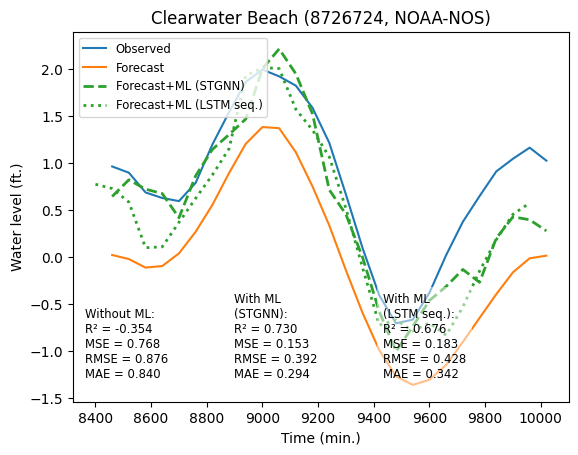

In [42]:
plt.plot(df_plot['time_UTC_dt'], df_plot['observed_data'], label='Observed')
plt.plot(df_plot['time_UTC_dt'], df_plot['forecast_data'], label='Forecast')
plt.plot(df_plot['time_UTC_dt'], df_plot['corr_forecast_data'], label='Forecast+ML (STGNN)', linestyle='dashed', linewidth=2)
plt.plot(df_plot_LSTM['time_UTC_dt'], df_plot_LSTM['corr_forecast_data'], label='Forecast+ML (LSTM seq.)', color='#2ca02c', linestyle='dotted', linewidth=2)

plt.xlabel('Time (min.)')
plt.ylabel('Water level (ft.)')

# stats for observed - forecast
r_sq_str = "R\u00b2 = {:.3f}\n".format(evaluation_stats[0])
mse_str = "MSE = {:.3f}\n".format(evaluation_stats[1])
rmse_str = "RMSE = {:.3f}\n".format(evaluation_stats[2])
mae_str = "MAE = {:.3f}\n".format(evaluation_stats[3])
stat_str = 'Without ML:\n' + r_sq_str + mse_str + rmse_str + mae_str
annotation = plt.annotate(stat_str, xy=(0.025, 0.025), xycoords='axes fraction', fontsize='small')
annotation.set_bbox(dict(facecolor='white', alpha=0.5, linewidth=0))

# stats for observed - corr. forecast (STGNN)
r_sq_str = "R\u00b2 = {:.3f}\n".format(evaluation_stats[4])
mse_str = "MSE = {:.3f}\n".format(evaluation_stats[5])
rmse_str = "RMSE = {:.3f}\n".format(evaluation_stats[6])
mae_str = "MAE = {:.3f}\n".format(evaluation_stats[7])
stat_str = 'With ML\n(STGNN):\n' + r_sq_str + mse_str + rmse_str + mae_str
annotation = plt.annotate(stat_str, xy=(0.325, 0.025), xycoords='axes fraction', fontsize='small')
annotation.set_bbox(dict(facecolor='white', alpha=0.5, linewidth=0))

# stats for observed - corr. forecast (LSTM)
r_sq_str = "R\u00b2 = {:.3f}\n".format(evaluation_stats_LSTM[4])
mse_str = "MSE = {:.3f}\n".format(evaluation_stats_LSTM[5])
rmse_str = "RMSE = {:.3f}\n".format(evaluation_stats_LSTM[6])
mae_str = "MAE = {:.3f}\n".format(evaluation_stats_LSTM[7])
stat_str = 'With ML\n(LSTM seq.):\n' + r_sq_str + mse_str + rmse_str + mae_str
annotation = plt.annotate(stat_str, xy=(0.625, 0.025), xycoords='axes fraction', fontsize='small')
annotation.set_bbox(dict(facecolor='white', alpha=0.5, linewidth=0))


plt.legend(loc='upper left', fontsize='small')
title_str = station_name + f' ({str(id)}, {agency})'
plt.title(title_str)
# plt.savefig(filename_plot)
plt.show()